In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Why Differentiable?

This is the page that explains what makes ``brainmass`` different. Other
whole-brain toolkits run forward simulations and fit parameters with **grid** or
**evolutionary** search. ``brainmass`` is built on JAX, so its entire pipeline —
parameters → ODE solve → coupling → forward model → signal — is **differentiable**.
You can backpropagate *through the ODE solve* and obtain the exact gradient of a
loss with respect to every parameter at once.

That single capability changes how you fit, scale, and even *train* neural mass
models. This page builds the intuition, walks through the new application
scenarios it unlocks, and places ``brainmass`` next to The Virtual Brain and
neurolib with a conservative comparison.

## The core idea: backprop through the solve

A whole-brain simulation is a long composition of differentiable operations. A
fixed-step solver advances the state $s$ by repeatedly applying an update map,

$$
s_{t+1} = \Phi(s_t, \theta), \qquad t = 0, 1, \dots, T-1,
$$

where $\theta$ collects all parameters (local model parameters, coupling strength,
forward-model constants). A scalar loss $\mathcal{L}$ compares the resulting
signal to data. Because every step $\Phi$ is differentiable, the whole rollout is
differentiable, and the chain rule gives

$$
\frac{\partial \mathcal{L}}{\partial \theta}
= \sum_{t} \frac{\partial \mathcal{L}}{\partial s_T}
  \left(\prod_{k>t} \frac{\partial \Phi}{\partial s_k}\right)
  \frac{\partial \Phi}{\partial \theta}.
$$

**Reverse-mode automatic differentiation** (backpropagation through time) computes
this entire sum in *one backward pass* whose cost is a small constant multiple of
the forward simulation — **independent of the number of parameters**. JAX builds
the backward pass automatically; you never write it.

Contrast this with the standard alternatives:

- **Grid search** evaluates the loss on a lattice of parameter values. The number
  of points grows as $(\text{resolution})^{\,d}$ in the parameter dimension $d$ —
  the curse of dimensionality. Feasible for 1–2 parameters, hopeless for many.
- **Evolutionary / derivative-free search** (CMA-ES, differential evolution,
  Nevergrad) needs *many* forward evaluations to estimate a good direction, and
  the count climbs steeply with $d$. Robust and gradient-free, but sample-hungry.

A gradient points *directly downhill*. Instead of probing the loss landscape with
hundreds of blind forward runs, you get the steepest-descent direction from a
single forward+backward pass and step along it.

## A picture: gradient vs blind search

Consider fitting a single parameter (a region's Hopf bifurcation parameter $a$) so
that the model's settled oscillation amplitude matches a target. The loss is a
smooth bowl in $a$. A gradient tells us the slope at our current guess for *free*
(one backward pass); grid/evolutionary methods would instead sample the bowl at
many points to infer the same direction. Let's visualise that loss surface and the
exact gradient at one point.

In [2]:
import brainmass
import brainstate
import braintools
import brainunit as u
import jax
import jax.numpy as jnp

brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)


def settled_amplitude(a_value):
    # Build the model INSIDE the loss so the swept scalar is differentiated.
    node = brainmass.HopfStep(in_size=1, a=a_value, w=0.3,
                              init_x=braintools.init.Constant(0.5))
    res = brainmass.Simulator(node, dt=0.1 * u.ms).run(
        400 * u.ms, monitors=['x'], transient=200 * u.ms)
    x = u.get_magnitude(res['x'])           # strip units before the reduction
    return jnp.sqrt(jnp.mean(x ** 2)) * jnp.sqrt(2.0)   # RMS -> amplitude


target = 1.0  # amplitude we want to match

def loss(a_value):
    return (settled_amplitude(a_value) - target) ** 2

# The exact gradient of the loss wrt `a`, by backprop THROUGH the 2000-step solve.
a0 = 0.4
g = jax.grad(loss)(a0)
print(f'loss({a0}) = {loss(a0):.4f}')
print(f'exact d(loss)/da at a={a0}: {g:.4f}   (one backward pass through the solve)')

loss(0.4) = 0.1332
exact d(loss)/da at a=0.4: -0.5733   (one backward pass through the solve)


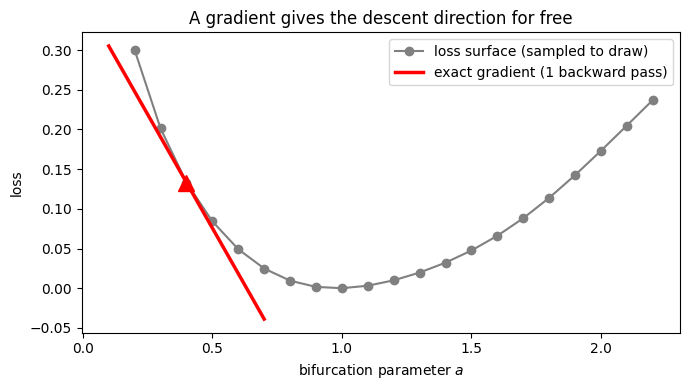

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Sample the loss bowl just to DRAW it; the optimiser never needs this many runs.
a_grid = np.linspace(0.2, 2.2, 21)
losses = [float(loss(float(a))) for a in a_grid]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(a_grid, losses, 'o-', color='0.5', label='loss surface (sampled to draw)')

# Draw the exact gradient at a0 as a tangent line.
l0 = float(loss(a0))
ax.plot([a0 - 0.3, a0 + 0.3], [l0 - 0.3 * float(g), l0 + 0.3 * float(g)],
        'r-', lw=2.5, label='exact gradient (1 backward pass)')
ax.plot([a0], [l0], 'r^', ms=11)
ax.set_xlabel('bifurcation parameter $a$')
ax.set_ylabel('loss')
ax.set_title('A gradient gives the descent direction for free')
ax.legend()
fig.tight_layout()
plt.show()

The red tangent is the exact slope at our current guess, computed from a single
forward+backward pass. Grid search would need the whole grey curve; evolutionary
search would need many scattered samples to *estimate* that slope. With the
gradient in hand, an optimiser steps straight toward the minimum — and the same
mechanism scales to thousands of parameters with no extra cost per parameter.

The hands-on version of this fit (with a real optimiser loop) is
{doc}`/tutorials/06_fitting_with_gradients`.

## New application scenarios

Differentiability is not just "faster fitting of one knob." It opens qualitatively
new ways of working that grid/evolutionary search cannot reach.

### 1. Efficient subject-specific fitting

Personalising a whole-brain model to one subject means fitting many local and
coupling parameters to that subject's data. With gradients, a quasi-Newton or Adam
optimiser converges in tens of iterations regardless of the parameter count,
turning an overnight evolutionary search into minutes. Per-subject fits become
routine rather than a compute project.

### 2. High-dimensional parameter *fields*

You are no longer restricted to a few global knobs. You can give **every region**
(or every edge) its own parameter — a spatial *field* of excitability, gain, or
coupling — and fit all of them jointly, because the gradient w.r.t. a
thousand-dimensional field costs the same backward pass as the gradient w.r.t. one
scalar. This is simply infeasible with grid search and painfully sample-hungry for
evolutionary methods.

### 3. Gradient- and Hessian-based identifiability

The gradient (and, via JAX, the **Hessian** or Fisher information) tells you about
the *geometry* of the loss around an optimum: which parameter combinations are
well-constrained by the data and which are sloppy. This is the basis of
identifiability and sensitivity analysis — and it falls out of the same autodiff
machinery, with no finite-difference noise.

### 4. Training NMM networks on tasks

Because the rollout is differentiable end-to-end, a network of neural masses can be
**trained** the way a recurrent neural network is — minimise a task loss
(classification, working memory, prediction) by gradient descent on the model's
parameters. The model becomes a trainable, biologically-structured RNN. See
{doc}`/tutorials/08_training_on_tasks` for a worked delayed-match-to-sample task.

### 5. End-to-end differentiable parameters → signal

The forward models (BOLD hemodynamics, EEG/MEG lead fields) are themselves
differentiable, so the gradient flows *all the way* from a neuroimaging-space loss
back to the underlying neural parameters. You can fit directly in BOLD or sensor
space — parameters → activity → signal → loss — without hand-deriving any
sensitivities.

## When *not* to use gradients

Gradients are powerful but not universal, and ``brainmass`` is honest about this —
the same ``Fitter`` exposes gradient-free backends for good reason:

- **Non-smooth or phase-degenerate objectives.** Matching an oscillatory time
  series point-by-point has a flat / degenerate gradient (a phase mismatch kills
  it). Fit a **scalar summary** — amplitude, functional connectivity, a spectral
  peak — instead, or fall back to a derivative-free backend.
- **Rugged, multi-modal landscapes** where you need global exploration: a
  population-based method (Nevergrad's differential evolution) may find the basin
  that gradient descent then refines.
- **Discrete or non-differentiable parameters.**

``brainmass.Fitter`` lets you write the objective **once** and switch between
``backend='grad'``, ``'nevergrad'``, and ``'scipy'`` — see
{doc}`/tutorials/07_gradient_free_fitting`. Differentiability is the *default
advantage*, not a straitjacket.

## How brainmass compares

``brainmass`` shares the neural-mass / whole-brain modelling space with
[The Virtual Brain](https://www.thevirtualbrain.org/) (TVB) and
[neurolib](https://github.com/neurolib-dev/neurolib). Both are mature, widely-used,
and excellent — but both are built on **NumPy/Numba**, run forward simulations, and
fit parameters with grid or evolutionary search. Neither has an automatic-
differentiation / JAX core, so neither can backpropagate through the solve or run
natively on GPU/TPU.

The table below mirrors the landing-page summary. It is deliberately
**conservative**: "Partial" means a capability exists in some form but is narrower
than ``brainmass``'s, and the picture reflects the state of these projects at the
time of writing — consult each project for its current status.

| Capability | brainmass | The Virtual Brain | neurolib |
|---|---|---|---|
| Differentiable / gradient-based fitting (backprop through the solve) | Yes | No | No |
| JAX backend with GPU / TPU acceleration | Yes | No | No |
| In-package orchestration & fitting (``Simulator`` / ``Network`` / ``Fitter``) | Yes | Partial | Partial |
| Unit-safe quantities (dimensional analysis) | Yes | No | No |
| Next-generation / exact mean-field models (e.g. Montbrió-Pazó-Roxin, Coombes-Byrne) | Yes | Partial | Partial |
| In-package BOLD + EEG/MEG forward models | Yes | Yes | Partial |

A few notes to keep the claims fair:

- **TVB and neurolib are not autodiff/JAX frameworks.** They are numpy/numba-based.
  This is a factual statement about backend, not a judgement of quality — TVB in
  particular has the richest connectome tooling, GUI, and community in the field.
- **"In-package forward models."** TVB ships BOLD and EEG/MEG forward models, so it
  earns a "Yes." neurolib focuses on BOLD, hence "Partial."
- **"Next-generation mean fields."** All three offer some next-generation models;
  ``brainmass`` derives several (Montbrió-Pazó-Roxin, Coombes-Byrne) *exactly* from
  spiking networks, which is the differentiator behind the "Yes."

The deeper rationale for the JAX-native choice is the whole of this page; the
landing page links back here for exactly that reason.

## Where to go next

This page is the conceptual hub for the differentiable workflow. The hands-on path
through it is:

- {doc}`/tutorials/06_fitting_with_gradients` — fit a parameter by backprop through
  the ``Simulator`` (the worked version of the example above).
- {doc}`/tutorials/07_gradient_free_fitting` — the same objective with Nevergrad and
  SciPy backends, head-to-head with gradients.
- {doc}`/tutorials/08_training_on_tasks` — *train* a neural-mass network on a task.
- {doc}`/data_driven/index` — the data-driven modelling hub that curates the full
  differentiable workflow and its roadmap.

And for the conceptual neighbours:

- {doc}`/concepts/what_is_a_neural_mass_model` — what these models are.
- {doc}`/concepts/architecture_overview` — how the differentiable pipeline is built.

## References

- Baydin, A. G., Pearlmutter, B. A., Radul, A. A., & Siskind, J. M. (2018).
  Automatic differentiation in machine learning: a survey. *Journal of Machine
  Learning Research*, 18(153), 1–43.
- Bradbury, J., et al. (2018). *JAX: composable transformations of Python+NumPy
  programs*. http://github.com/google/jax
- Sanz Leon, P., et al. (2013). The Virtual Brain: a simulator of primate brain
  network dynamics. *Frontiers in Neuroinformatics*, 7, 10.
- Cakan, C., Jajcay, N., & Obermayer, K. (2023). neurolib: a simulation framework
  for whole-brain neural mass modeling. *Cognitive Computation*, 15, 1132–1152.
- Montbrió, E., Pazó, D., & Roxin, A. (2015). Macroscopic description for networks
  of spiking neurons. *Physical Review X*, 5(2), 021028.